This notebook runs through elements of the optimized first wedge and the QQ+Sector Dipole dispersion suppressor.

Written by: Inci Karaaslan

Created: 2/22/2026

# Setup

In [6]:
# Important! All of the functions utilized in this notebook unless defined here comes from these two scripts. 
# For more information on the functions, check scan.py and g4beam.py!!
from scan import *
from g4beam import *

import math
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib import cm
import numpy as np
import pandas as pd
from tqdm import *
import pickle
import itertools
from tabulate import tabulate
from scipy.optimize import differential_evolution
import re

In [7]:
# Make Sure g4bl path is in here -- change the "/home/incik/G4beamline-3.08/bin" with your "G4beamline-3.08/bin" path
import os
os.environ["PATH"] += os.pathsep + "/home/incik/G4beamline-3.08/bin"
import shutil
print(shutil.which("g4bl"))

/home/incik/G4beamline-3.08/bin/g4bl


# Initial distribution

First Wedge Optimization done by Daniel Fu: A Gaussian beam is generated using Mike Syphers' theoretical description of the parameters needed via https://nicadd.niu.edu/~syphers/tutorials/analyzeTrack.html#analyzing-a-distribution.

The parameters of the initial beam are treated as constants, but some things are known about their effects:
- **Transverse emittance**: Should be as low as possible. For this test we use an "optimistic" value of 110 microns.
- **Momentum**: Decreasing this appears to slightly decreases x-emittance.
- **Beta**: Decreasing this decreases the y-emittance growth. There may also be an optimal value for x-emittance.
- **Alpha**: Increasing this decreases the y-emittance growth, but past a certain point increases the x-emittance. I believe 0.7 focuses the beam onto the wedge center with a VD distance of 24 mm.
- **Longitudinal emittance**: Effects not yet tested.
- **Standard deviation of momentum**: Decreasing this decreases the x-emittance.
- **Virtual detector distance**: Almost irrelevant. Should be more than 3x the length of the wedge to ensure accurate measurements.

In [8]:
t_emit = 0.145  # mm
momentum = 100  # MeV/c
beta = 0.03    # m
alpha = 0.7     # dimensionless
l_emit = 1      # mm
pz_std = 1    # MeV/c
vd_dist = 24    # mm

pre_w1 = gen_distribution((beta, alpha, t_emit, 0, 0), (beta, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit, N=20000)
pre_w1["PDGid"] = -13
print_all_params(pre_w1)

-----------------------------
Twiss parameters for X
emit  = 0.14536886136105084 mm
beta  = 0.029850271469690434 m
gamma = 49.42677987812451 1/m
alpha = 0.689494595507934
D     = -0.00012284249476919647 m
D'    = -0.0619793821721043

Twiss parameters for Y
emit  = 0.14655927168482663 mm
beta  = 0.02995634074617899 m
gamma = 49.25771752261345 1/m
alpha = 0.6896237890955037
D     = 0.0010874522868888367 m
D'    = -0.0726617169867417

Z-emittance:  1.26156160323735 mm
Z std: 153.3843483495815 mm
p std: 1.004929578178683 MeV/c
Mean momentum: 99.9990428188336 MeV/c
-----------------------------


In [9]:
write_trackfile(pre_w1, "particles_before_firstwedge.txt")

# First wedge -- Run Optimized Value

In [10]:
post_w1 =  run_g4beam(pre_w1, "G4_FinalCooling_auto.g4bl")
print_all_params(post_w1)

-----------------------------
Twiss parameters for X
emit  = 0.046498974584313325 mm
beta  = 0.03446791467136244 m
gamma = 185.6637038047068 1/m
alpha = -2.3236696624756594
D     = 0.020129561350157518 m
D'    = -0.04502518938937676

Twiss parameters for Y
emit  = 0.15115748088905148 mm
beta  = 0.025636847253466072 m
gamma = 57.24699789625017 1/m
alpha = -0.6838366331117831
D     = -0.00010771838752918229 m
D'    = 0.008876184139905352

Z-emittance:  6.387105549813547 mm
Z std: 142.90858551943106 mm
p std: 7.207781270156738 MeV/c
Mean momentum: 87.96486456860053 MeV/c
-----------------------------


In [11]:
# Write the wedge output into a file
write_trackfile(post_w1, "particles_after_firstwedge.txt")

In [12]:
# Optimized G4_FinalCooling_auto.g4bl parameters
w1_length = 7.08 #mm
w1_angle = 47.2 #deg
offset = w1_length / (math.tan(w1_angle * math.pi / 180) * 2)
base_length = 24
abswidth = 100
parameters = dict(
        abshalfangle3=str(w1_angle),
        absoffset3=str(offset),
        abshgt=str(offset * base_length / w1_length + 0.1),
        absLEN3=str(base_length)
    )
L_centerline = float(parameters['absLEN3']) + 1
print("Where to put the next element: " + str(L_centerline) + "mm")

Where to put the next element: 25.0mm


In [13]:
# If particles_after isn't updated with Z = 0, so if we want to use the resulting distribution as the initial distribution
# for each of the files, we must set the particle distribution we get after to have a z of 0.
def convertZ(input_file, output_file, set_to=0):
    event_id_counter = 1
    with open(input_file, "r") as infile, open(output_file, "w") as outfile:
        for line in infile:
            # Skip header lines (those starting with #)
            if line.strip().startswith("#"):
                outfile.write(line)
                continue

            # Split the line into columns
            parts = line.strip().split()
            if len(parts) >= 12:
                parts[2] = str(set_to)  # Set the 3rd column (z) to 0
                # Replace event ID (assuming it's the 9th column, zero-based index 8)
                # Adjust if your event ID is in a different column
                parts[8] = str(event_id_counter)
                event_id_counter += 1
                new_line = " ".join(parts)
                outfile.write(new_line + "\n")
            else:
                # Handle lines that don't match expected format
                outfile.write(line)
    print(f"Updated file saved as '{output_file}'")
    os.remove(input_file)
    return None

In [14]:
convertZ("particles_after_firstwedge.txt", "particles_after_firstwedgeupt.txt", set_to=0.0)

Updated file saved as 'particles_after_firstwedgeupt.txt'


# Dispersion correction optimized

The main goal is to have $D_x \approx 0$ up to 1e-5 m while keeping $\beta_x$ relatively periodic and about at the same value.

In [15]:
# Write values to the prepared G4BL template
def write_input_from_template(template_path, replacements, out_path):
    with open(template_path, 'r') as f:
        txt = f.read()
    try:
        txt = txt.format(**replacements)
    except KeyError as e:
        raise RuntimeError(f"Template substitution failed; missing placeholder: {e}")
    with open(out_path, 'w') as f:
        f.write(txt)

In [16]:
def clean_field_files():
    for f in ["field_cellBSec.dat", "field_cellQ2.dat"]:
        if os.path.exists(f):
            os.remove(f)

In [17]:
# Beta and Dispersion we have from after the wedge:
x0_params, y0_params, _ = calc_all_params(post_w1)
beta_x_ref= x0_params[1]; beta_y_ref= y0_params[1]
print(r"$\beta_x$: " + str(beta_x_ref), r"$\beta_y$: " + str(beta_y_ref))
print("D_x: " + str(x0_params[4]), "D_y: " + str(y0_params[4]))

$\beta_x$: 0.03446791467136244 $\beta_y$: 0.025636847253466072
D_x: 0.020129561350157518 D_y: -0.00010771838752918229


In [18]:
def beam_size(beta, eps, n_sigma=15):
    """
    Compute full beam width/height in mm for given beta (m) and emittance (mm·mrad)
    """
    sigma = np.sqrt(beta * eps * 1e3)  # convert sigma (mm) = sqrt(m * 1e3 * mm)
    return n_sigma * sigma

n_sigma_x = beam_size(x0_params[1], x0_params[0])
n_sigma_y = beam_size(y0_params[1], y0_params[0])
print("Determine the Quad Width: " + str(n_sigma_x),"Determine the Quad Height: " + str(n_sigma_y))
radius_q = max(n_sigma_x, n_sigma_y)
print("So the quad radius: " + str(radius_q) + " mm")
B_pole_max = 2.0
gradBound = B_pole_max / (radius_q*1e-3)
print(f"Max gradient bound for quads : ({-gradBound}, {gradBound}) ")

Determine the Quad Width: 18.98980265464972 Determine the Quad Height: 29.528296276174643
So the quad radius: 29.528296276174643 mm
Max gradient bound for quads : (-67.73164226253482, 67.73164226253482) 


In [19]:
def run_two_quadrupoles(df, Q1_gradient, Q2_gradient, Drift1_length, Q1_length=100, Q2_length=100, Q1_radius=radius_q, Q2_radius=radius_q, Q1_z=L_centerline, thickness=5):
    """
    Runs G4BL with two sequential quadrupoles.
    """
    Drift1_width=2*max(Q1_radius,Q2_radius)
    Drift1_height=2*max(Q1_radius,Q2_radius)
    # Q1_z : f"{L_centerline + (Q1_length / 2):.12f}",
    params = {
    "Q1_z": f"{Q1_z + (Q1_length / 2):.12f}",
    "Q1_length": f"{Q1_length:.12f}",
    "Q1_gradient": f"{Q1_gradient:.12f}",
    "radius_q1": f"{Q1_radius:.12f}",
    "radius_q2": f"{Q2_radius:.12f}",
    "thickness": f"{thickness:.12f}",
    "Q1_end": f"{Q1_z + Q1_length:.12f}",
    "Q2_length":f"{Q2_length:.12f}",
    "Q2_gradient": f"{Q2_gradient:.12f}",
    "Drift1_length": f"{Drift1_length:.12f}",
    "Drift1_z": f"{Q1_z + Q1_length + (Drift1_length / 2):.12f}",
    "Drift1_width": f"{Drift1_width:.12f}", 
    "Drift1_height":f"{Drift1_height:.12f}",
    "D1_end": f"{Q1_z + Q1_length + Drift1_length:.12f}",
    "Q2_z": f"{Q1_z + Q1_length + Drift1_length + Q2_length/2:.12f}",
    "Q2_end": f"{Q1_z + Q1_length + Drift1_length + Q2_length:.12f}",
    }

    print("PARAMS PASSED TO TEMPLATE:")
    for k, v in params.items():
        print(k, "=", v)
    write_input_from_template("G4_FinalCooling_dispsup_Q2.g4bl", params, "G4_FinalCooling_dispsup_Q2_run.g4bl")
    
    # Run this file
    res = run_g4beam(df, "G4_FinalCooling_dispsup_Q2_run.g4bl")

    if res is None or len(res) < 10:
        print("G4BL run failed or empty. Check template and parameters.")
        return None
    return res

In [20]:
history = []
def optimize_qq_drift_safe(x, df, beta_x_ref, beta_y_ref,
                           w_disp=1.0, w_beta=1000.0, w_surv=10000.0):
    """
    Optimizer wrapper with:
    - Survival-aware penalty
    - Full diagnostics
    """

    q1_gradient, q2_gradient, d1_length = x
    print("\nTRYING x =", x)

    try:
        result = run_two_quadrupoles(df, q1_gradient, q2_gradient, d1_length)
    except Exception as e:
        print("EXCEPTION in run_two_quadrupoles:", e)
        return 1e6

    if result is None or len(result) == 0:
        print("No particles survived")
        return 1e6

    # Compute survival fraction
    N0 = 2000 # len(df)
    Ns = len(result)
    survival = Ns / N0
    survival_penalty = w_surv * (1.0 - survival)**2
    print(f"Particles survived: {Ns}/{N0} → penalty {survival_penalty:.3f}")

    # Compute optics parameters
    try:
        x_params, y_params, _ = calc_all_params(result)
    except Exception as e:
        print("EXCEPTION in calc_all_params:", e)
        return 1e5

    Dx = x_params[4]
    Dy = y_params[4]
    beta_x = x_params[1]
    beta_y = y_params[1]

    beta_penalty = ((beta_x - beta_x_ref)/beta_x_ref)**2 + ((beta_y - beta_y_ref)/beta_y_ref)**2
    eps = 1e-4

    # Log-scaled optics loss
    optics_loss = np.log(Dx**2 + eps) + w_beta * np.log(beta_penalty**2 + eps)

    # Total objective
    val = optics_loss + survival_penalty

    print(f"OBJECTIVE = {val:.6f}, Dx={Dx:.6f}, beta_penalty={beta_penalty:.6f}")
    history.append({
    "Q1_G": q1_gradient,
    "Q2_G": q2_gradient,
    "Drift1_L": d1_length,
    "Dx": Dx,
    "beta_x": beta_x,
    "beta_y": beta_y,
    "survival": survival,
    "objective": val})
    return val

In [21]:
x0 = [ -9.00758863, 11.56562394, 419.697143]
# Physical bounds
bounds = np.array([
    [-gradBound, gradBound],      # Q1_gradient
    [-gradBound, gradBound],    # Q2_gradient
    [20, 3000]    # Drift1_length
])
res = scipy.optimize.minimize(
    optimize_qq_drift_safe, x0,
    args=(post_w1, beta_x_ref, beta_y_ref),
    method="Nelder-Mead", bounds=bounds,
    options={"xatol":1e-4, "fatol":1e-6, "maxiter":500}
)
print("Optimal parameters:", res.x)


TRYING x = [ -9.00758863  11.56562394 419.697143  ]
PARAMS PASSED TO TEMPLATE:
Q1_z = 75.000000000000
Q1_length = 100.000000000000
Q1_gradient = -9.007588630000
radius_q1 = 29.528296276175
radius_q2 = 29.528296276175
thickness = 5.000000000000
Q1_end = 125.000000000000
Q2_length = 100.000000000000
Q2_gradient = 11.565623940000
Drift1_length = 419.697143000000
Drift1_z = 334.848571500000
Drift1_width = 59.056592552349
Drift1_height = 59.056592552349
D1_end = 544.697143000000
Q2_z = 594.697143000000
Q2_end = 644.697143000000


Particles survived: 232/2000 → penalty 7814.560
OBJECTIVE = 21406.780521, Dx=-0.008282, beta_penalty=898.255254

TRYING x = [ -9.45796806  11.56562394 419.697143  ]
PARAMS PASSED TO TEMPLATE:
Q1_z = 75.000000000000
Q1_length = 100.000000000000
Q1_gradient = -9.457968061500
radius_q1 = 29.528296276175
radius_q2 = 29.528296276175
thickness = 5.000000000000
Q1_end = 125.000000000000
Q2_length = 100.000000000000
Q2_gradient = 11.565623940000
Drift1_length = 419.697143000000
Drift1_z = 334.848571500000
Drift1_width = 59.056592552349
Drift1_height = 59.056592552349
D1_end = 544.697143000000
Q2_z = 594.697143000000
Q2_end = 644.697143000000
Particles survived: 228/2000 → penalty 7849.960
OBJECTIVE = 21538.731231, Dx=-0.004685, beta_penalty=942.835266

TRYING x = [ -9.00758863  12.14390514 419.697143  ]
PARAMS PASSED TO TEMPLATE:
Q1_z = 75.000000000000
Q1_length = 100.000000000000
Q1_gradient = -9.007588630000
radius_q1 = 29.528296276175
radius_q2 = 29.528296276175
thickness = 5.000000000000
Q

In [28]:
df_opt_q = run_two_quadrupoles(post_w1, Q1_gradient=res.x[0], Q2_gradient=res.x[1], Drift1_length=res.x[2])
print(df_opt_q)
write_trackfile(df_opt_q, "particles_after_q2.txt")

PARAMS PASSED TO TEMPLATE:
Q1_z = 75.000000000000
Q1_length = 100.000000000000
Q1_gradient = -2.556388749170
radius_q1 = 29.528296276175
radius_q2 = 29.528296276175
thickness = 5.000000000000
Q1_end = 125.000000000000
Q2_length = 100.000000000000
Q2_gradient = 28.581621109048
Drift1_length = 43.950950397025
Drift1_z = 146.975475198512
Drift1_width = 59.056592552349
Drift1_height = 59.056592552349
D1_end = 168.950950397025
Q2_z = 218.950950397025
Q2_end = 268.950950397025
            x         y        z         Px        Py       Pz         t  \
0    14.16550  25.46570  268.951  -6.114300  21.17840  93.7503  1.109250   
1    12.89450  -7.23151  268.951  -5.905640  -5.98293  92.5684  0.979176   
2     4.61422 -19.14390  268.951  -2.525490 -14.79700  94.3039  2.556660   
3   -16.57860 -15.04170  268.951   8.474160 -11.55940  79.5858  1.496220   
4   -25.25970  10.91450  268.951  11.048700   9.46865  86.0150  0.551642   
..        ...       ...      ...        ...       ...      ...      

In [29]:
x_params_q, y_params_q, z_emit_q = calc_all_params(df_opt_q)
print("Dx, Dy =", x_params_q[4], y_params_q[4])
b_dict = {"Beta_x" : x_params_q[1], "Beta_y" : y_params_q[1]}
print(b_dict)
with open("particles_after_q2.txt") as f:
    N_out = sum(1 for line in f if not line.startswith("#") and line.strip())
    print(N_out)
N_PARTICLES = 2000
# Compute transmission (%)
trans_percent = 100.0 * N_out / int(N_PARTICLES)
print("Transmission = ", trans_percent)

Dx, Dy = 0.005157795167598538 -0.005356847968330374
{'Beta_x': np.float64(0.25062700107381186), 'Beta_y': np.float64(0.4475758365280801)}
851
Transmission =  42.55


In [30]:
if os.path.exists("particles_after_q2upt.txt"):
    os.remove("particles_after_q2upt.txt")
convertZ("particles_after_q2.txt", "particles_after_q2upt.txt", set_to=0.0)
df_opt_q_zero = read_trackfile("particles_after_q2upt.txt")

Updated file saved as 'particles_after_q2upt.txt'


In [31]:
def check_dipole_clearance(df, B_val, B_radius, B_angle, B_thickness):
    """
    Check which particles clear the dipole aperture based on their Larmor radius
    and deflection geometry.

    Parameters:
      df : pandas.DataFrame with columns ['Px','Py','Pz'] in MeV/c
      B_val : magnetic field (Tesla)
      dipole_length_mm : dipole magnet effective length (mm)
      dipole_halfwidth_mm : half-width of dipole aperture (mm)

    Returns:
      surviving_mask : boolean array, True if particle clears aperture
      r_L_mm : array of Larmor radii (mm)
      delta_r_mm : array of deflections (mm)
    """
    dipole_length_mm = 2 * B_radius * math.sin(B_angle * math.pi/360)
    dipole_halfwidth_mm = B_thickness
    # constants
    e = 1.602176634e-19  # C
    c = 2.99792458e8     # m/s

    # convert MeV/c to SI (kg·m/s)
    mom_perp = np.sqrt(df["Px"]**2 + df["Pz"]**2) * 1e6 * e / c  # B assumed along y

    # Larmor radius [m]
    r_L = mom_perp / (e * np.abs(B_val))

    # convert to mm
    r_L_mm = r_L * 1e3
    s_mm = dipole_length_mm

    # deflection Δr = r * (1 - cos(φ)), φ = s / r
    phi = s_mm / r_L_mm
    delta_r_mm = r_L_mm * (1 - np.cos(phi))

    # check if deflection < half-width
    surviving_mask = delta_r_mm < dipole_halfwidth_mm
    

    return surviving_mask, r_L_mm, delta_r_mm

In [32]:
def run_dipole(df, B_field, B_angle, B_radius, B_z, B_thickness=50, B_height=100):
    if os.path.exists("field_cellB.dat"):
        os.remove("field_cellB.dat")
    """Run dipole simulation with given parameters."""
    params = {
        "B1_field": B_field,
        "B1_angle": B_angle,
        "B1_radius": B_radius,
        "B1_z": B_z,
        "B1_z_end": B_z + 2 * (B_radius * B_angle * math.pi/360)+0.1,
        "B1_x_end": B_z - B_thickness * math.sin(B_angle * math.pi/360),
        "B1_thickness": B_thickness,
        "B1_height": B_height
    }
    write_input_from_template("G4_FinalCooling_dispsup_B.g4bl", params, "G4_FinalCooling_dispsup_B_run.g4bl")
    # Run G4Beamline
    df_out = run_g4beam(df, "G4_FinalCooling_dispsup_B_run.g4bl")

    return df_out

In [33]:
def optimize_dipole(x, df_in, beta_x_ref, beta_y_ref, 
                    w_disp=1000.0, w_beta=10.0, w_clear=100.0, 
                    D_tol=1e-4, survival_threshold=0.95):
    """
    Optimize dipole parameters using G4Beamline simulations.

    Parameters
    ----------
    x : array-like
        Dipole parameters: [B_field, B_angle_deg, B_radius]
    df_in : pandas.DataFrame
        Input particle distribution
    beta_x_ref, beta_y_ref : float
        Target beta functions
    w_disp, w_beta : float
        Weights for cost function
    survival_threshold : float
        Minimum fraction of particles that must survive

    Returns
    -------
    float
        Objective function value (smaller is better)
    """
    # Unpack parameters
    B_field, B_angle, B_radius, B_z = x
    B_thickness = 50.0
    B_height = 100.0

    # Run dipole simulation
    result = run_dipole(df_in, B_field, B_angle, B_radius, B_z)
    if result is None or len(result) == 0:
        # no particles survived, penalize heavily
        return 1e6

    mask, r_L_mm, delta_r_mm = check_dipole_clearance(df_in, B_field, B_angle, B_radius, B_thickness)
    mask = mask[:len(result)]  # truncate if needed
    if len(result) == 0:
        survival_frac = 0.0
    else:
        if isinstance(result, np.ndarray):
            df_survived = result[mask]
        else:
            df_survived = result[mask.values]
        survival_frac = len(df_survived) / len(df_in)

    if survival_frac < survival_threshold:
        return 1e6 + 1e3*(survival_threshold - survival_frac)
    """N0 = len(df_in)
    Ns = len(result)
    survival = Ns / N0
    survival_penalty = (1.0 - survival)**2"""


    # Compute dispersion & beta from survived particles
    df_survived = result[mask] if isinstance(result, np.ndarray) else result[mask.values]
    x_params_d, y_params_d, _ = calc_all_params(df_survived)
    # print_all_params(result)
    Dx, beta_x = x_params_d[4], x_params_d[1]
    Dy, beta_y = y_params_d[4], y_params_d[1]

    # Penalties
    disp_penalty = ((Dx - 0)/D_tol)**2  # target dispersion = 0 at end
    beta_penalty = ((beta_x - beta_x_ref)/beta_x_ref)**2 + ((beta_y - beta_y_ref)/beta_y_ref)**2

    # Total objective function
    val = w_disp * disp_penalty + w_beta * beta_penalty
    print(f"Objective = {val:.3f}, Survival = {survival_frac:.3f}, Dx = {Dx:.4f}, beta_x = {beta_x:.3f}, beta_y = {beta_y:.3f}")
    return val

In [34]:
start = time.time()
# Run optimization
optim_result = minimize(optimize_dipole, [1.5, 2.0, 1000.0, 1.0], args=(df_opt_q_zero, b_dict["Beta_x"], b_dict["Beta_y"]), method="Nelder-Mead", bounds=((0.1, 3.0), (1.0, 10.0), (100.0, 2000.0), (0.5, 1000.0)), options=dict(fatol=1e-6))

# Get results
B_field, B_angle, B_radius, B_z = optim_result.x
print(f"Field = {B_field:.2f} T \nAngle = {B_angle:.2f} deg\nRadius = {B_radius:.1f} mm\nSpacing = {B_z:.1f} mm")
print("Time spent:", time.time()-start)

iter value
Objective = 410075.354, Survival = 0.981, Dx = 0.0020, beta_x = 0.243, beta_y = 1.043
Objective = 488766.986, Survival = 0.981, Dx = 0.0022, beta_x = 0.243, beta_y = 1.043
Objective = 469706.463, Survival = 0.981, Dx = 0.0022, beta_x = 0.240, beta_y = 1.068
Objective = 470242.877, Survival = 0.981, Dx = 0.0022, beta_x = 0.240, beta_y = 1.068
Objective = 407441.154, Survival = 0.981, Dx = 0.0020, beta_x = 0.243, beta_y = 1.043
Objective = 384750.111, Survival = 0.981, Dx = 0.0020, beta_x = 0.240, beta_y = 1.068
Objective = 329898.378, Survival = 0.981, Dx = 0.0018, beta_x = 0.238, beta_y = 1.081
Objective = 345731.886, Survival = 0.981, Dx = 0.0019, beta_x = 0.242, beta_y = 1.049
Objective = 298500.984, Survival = 0.981, Dx = 0.0017, beta_x = 0.243, beta_y = 1.040
Objective = 237929.269, Survival = 0.981, Dx = 0.0015, beta_x = 0.245, beta_y = 1.026
Objective = 247839.073, Survival = 0.981, Dx = 0.0016, beta_x = 0.241, beta_y = 1.056
Objective = 180396.892, Survival = 0.981, D

In [35]:
opt_params = {
        "B1_field": optim_result.x[0],
        "B1_angle": optim_result.x[1],
        "B1_radius": optim_result.x[2],
        "B1_z": optim_result.x[3],
        "B1_z_end": optim_result.x[3] + 2 * (optim_result.x[2] * optim_result.x[1] * math.pi/360)+0.1,
        "B1_x_end": optim_result.x[3] - 50 * math.sin(optim_result.x[1] * math.pi/360),
        "B1_thickness": 50,
        "B1_height": 100,
    }
if os.path.exists("field_cellB.dat"):
    os.remove("field_cellB.dat")
write_input_from_template("G4_FinalCooling_dispsup_B.g4bl", opt_params, "G4_FinalCooling_dispsup_B_opt2.g4bl")
df_dip = run_g4beam(df_opt_q, "G4_FinalCooling_dispsup_B_opt2.g4bl")

In [36]:
write_trackfile(df_dip, "particles_after_b.txt")

if os.path.exists("particles_after_bupt.txt"):
    os.remove("particles_after_bupt.txt")
convertZ("particles_after_b.txt",  "particles_after_bupt.txt")

x_params_dip, y_params_dip, z_emit_dip = calc_all_params(df_dip)
D_dict_dip = {"D_x": x_params_dip[4], "D'_x": x_params_dip[5], "D_y": y_params_dip[4], "D'_y": y_params_dip[5]}
b_dict_dip = {"Beta_x": x_params_dip[1], "Beta_y": y_params_dip[1]}
print(D_dict_dip, r"Epsilon_z: "+str(z_emit_dip), b_dict_dip)

Updated file saved as 'particles_after_bupt.txt'
{'D_x': np.float64(4.5849830257607524e-08), "D'_x": np.float64(-0.04557222448990703), 'D_y': np.float64(-0.008338933297010106), "D'_y": np.float64(-0.06175483057866619)} Epsilon_z: 5.952671363368689 {'Beta_x': np.float64(0.23484239968359552), 'Beta_y': np.float64(1.0297716634079053)}


In [159]:
calc_all_params(df_dip)

((np.float64(0.445803425191373),
  np.float64(0.23484239968359552),
  np.float64(7.103042689168227),
  np.float64(0.8173711459179888),
  np.float64(4.5849830257607524e-08),
  np.float64(-0.04557222448990703)),
 (np.float64(0.34231763277661026),
  np.float64(1.0297716634079053),
  np.float64(43.62321657695496),
  np.float64(-6.6273639026127285),
  np.float64(-0.008338933297010106),
  np.float64(-0.06175483057866619)),
 np.float64(5.952671363368689))

[[  0.    0.    0.    0.    0.    0. ]
 [  0.    0.    0.5   0.    0.    0. ]
 [  0.    0.    1.    0.    0.    0. ]
 ...
 [  0.    0.  498.5   0.    0.    0. ]
 [  0.    0.  499.    0.    0.    0. ]
 [  0.    0.  499.5   0.    0.    0. ]]
{'COLORS': 100.0}


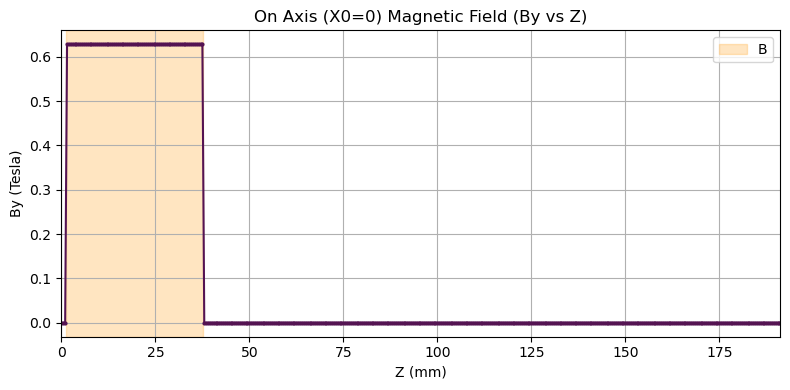

In [37]:
def fieldEvolution():
    """ 
    Evolution of the magnetic field across elements, plotted. 
    
    """
    # Load file, skipping comment lines
    with open("field_cellB.dat") as f:
        lines = f.readlines()[4:]
    
    data = np.array([[float(x) for x in line.split()] for line in lines])
    print(data)
    
    # If the file has columns: x y z Bx By Bz
    # then we can extract:
    z = data[:, 2]
    by = data[:, 4]
    
    
    # Draw shaded regions for magnets
    # Read your g4bl file
    with open("G4_FinalCooling_dispsup_B_opt.g4bl") as f:
        text = f.read()

    # Extract magnets (dipoles, quads, drifts, etc.)
    pattern = r"\s*([A-Za-z0-9_]+):\s*([-\d\.]+)"
    entries = dict(re.findall(pattern, text))
    
    # Convert numeric values
    params = {k: float(v) for k, v in entries.items()}
    print(params)
    magnet_colors = {
            "B":     "#FFAA33",   # warm orange
        }

    regions = []
    length = optim_result.x[3] + 2 * (optim_result.x[2] * optim_result.x[1] * math.pi/360)+0.1
    z1 = optim_result.x[3]
    z2 = length
    regions.append((z1, z2, "#FFAA33", "B"))

    plt.figure(figsize=(8, 4))
    for z1, z2, color, label in regions:
        if z1 is not None and z2 is not None:
            plt.axvspan(z1, z2, color=color, alpha=0.3, label=label)
    
    plt.plot(z, by, '-o', color="#541352FF", markersize=2)
    plt.xlim(0.0, (730.1 * 10 *math.pi/360) *3)
    plt.xlabel("Z (mm)")
    plt.ylabel("By (Tesla)")
    plt.title("On Axis (X0=0) Magnetic Field (By vs Z)")
    plt.grid(True)
    plt.tight_layout()
    plt.legend()
    plt.savefig("Bfields.png")

fieldEvolution()

In [38]:
import re

def parse_magnets_from_g4bl(filename):

    magnet_colors = {
        "Q1": "#6699FF",
        "Drift1": "#BBBBBB",
        "Q2": "#6699FF",
        "B1": "#FFAA33"
    }

    regions = []

    with open(filename) as f:
        text = f.read()

    # ----------------------------
    # Find quadrupoles
    # ----------------------------
    quad_pattern = r"genericquad\s+(\w+).*?fieldLength\s*=\s*([-+]?\d*\.?\d+)"
    quads = re.findall(quad_pattern, text, re.DOTALL)

    # ----------------------------
    # Find dipoles (angle * radius)
    # ----------------------------
    dipole_pattern = (
        r"genericsectorbend\s+(\w+).*?"
        r"angle\s*=\s*([-+]?\d*\.?\d+).*?"
        r"fieldCenterRadius\s*=\s*([-+]?\d*\.?\d+)"
    )
    dipoles = re.findall(dipole_pattern, text, re.DOTALL)

    # Build length dictionary
    magnet_lengths = {}

    for name, length in quads:
        magnet_lengths[name] = float(length)
        
    for name, angle, radius in dipoles:
        magnet_lengths[name] = float(math.radians(float(angle))) * float(radius)

    # ----------------------------
    # Find placements
    # ----------------------------
    place_pattern = r"place\s+(\w+)\s+z\s*=\s*([-+]?\d*\.?\d+)"
    placements = re.findall(place_pattern, text)

    magnet_positions = {name: float(z) for name, z in placements}

    # ----------------------------
    # Build regions
    # ----------------------------
    for name in magnet_positions:
        if name in magnet_lengths and name in magnet_colors:

            pos = magnet_positions[name]
            length = magnet_lengths[name]

            if name.startswith("B"):   # dipole
                z1 = pos
                z2 = pos + length
            else:                      # quad
                z1 = pos - length/2
                z2 = pos + length/2

            regions.append((z1, z2, magnet_colors[name], name))

    return regions

In [39]:
write_trackfile(post_w1, "particles_after_firstwedge.txt")
write_trackfile(df_opt_q, "particles_after_q2.txt")
write_trackfile(df_dip, "particles_after_b.txt")

In [140]:
df_dip_zero = read_trackfile("particles_after_bupt.txt")

In [43]:
print(parse_magnets_from_g4bl("G4_FinalCooling_dispsup_B_run.g4bl"))

[(1.2787283982754145, 37.66561129341814, '#FFAA33', 'B1')]


In [41]:
def twissPlot(z_positions, emit_x, emit_y, emit_z, beta_x, beta_y, alpha_x, alpha_y, D_x, Dp_x, D_y, Dp_y, output_folder="./dispsup_plots"):
    
    # -------------------------------------------------------------------
    # CONVERT TO ARRAYS FOR PLOTTING
    # -------------------------------------------------------------------
    z_positions = np.array(z_positions)
    order = np.argsort(z_positions)

    z_positions = z_positions[order]
    emit_x = np.array(emit_x)[order]
    emit_y = np.array(emit_y)[order]
    beta_x = np.array(beta_x)[order]
    beta_y = np.array(beta_y)[order]
    alpha_x = np.array(alpha_x)[order]
    alpha_y = np.array(alpha_y)[order]
    D_x = np.array(D_x)[order]
    Dp_x = np.array(Dp_x)[order]
    D_y = np.array(D_y)[order]
    Dp_y = np.array(Dp_y)[order]
    emit_z = np.array(emit_z)[order]

    # -------------------------------------------------------------------
    # PLOTTING
    # -------------------------------------------------------------------
    def make_plot(yvals, ylabel, title, filename, labels=("x", "y")):
        plt.figure(figsize=(7,5))

        # ---- draw magnet shading (already parsed) ----
        for z1, z2, color, label in regions:
            plt.axvspan(z1, z2, color=color, alpha=0.3, label=label)

        # ---- twiss curves ----
        plt.plot(z_positions, yvals[0], 'o-', color="#541352FF", label=f"{labels[0]}-plane")
        plt.plot(z_positions, yvals[1], 's--', color="#3A5E8CFF", label=f"{labels[1]}-plane")

        plt.xlabel("z [mm]")
        plt.ylabel(ylabel)
        plt.title(title)
        plt.grid(True)

        # ---- remove duplicate legend entries ----
        handles, labels = plt.gca().get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        plt.legend(by_label.values(), by_label.keys())

        plt.tight_layout()
        plt.savefig(os.path.join(output_folder, filename))
        plt.close()


    make_plot((emit_x, emit_y), "Emittance [mm·mrad]",
            "Emittance Evolution", "emittance_evolution.png")

    make_plot((beta_x, beta_y), "β-function [m]",
            "Beta Function Evolution", "beta_evolution.png")

    make_plot((alpha_x, alpha_y), "α-function [–]",
            "Alpha Function Evolution", "alpha_evolution.png")

    make_plot((D_x, D_y), "Dispersion D [m]",
            "Dispersion Function", "dispersion_D.png")

    make_plot((Dp_x, Dp_y), "Dispersion Derivative D' [-]",
            "Dispersion Derivative", "dispersion_Dprime.png")

    print(f"All plots saved in '{output_folder}'")


files = [
    "particles_before_firstwedge.txt",
    "vd_Q1_dispsup.txt",
    "vd_D1_dispsup.txt",
    "particles_after_q2.txt",
    "particles_after_b.txt"
]

# -------------------------------------------------
# REPLACE YOUR OLD LOOP WITH THIS BLOCK
# -------------------------------------------------

z_positions = []
z_local_list = []
twiss_data = []

# First pass: read everything once
for f in files:
    df1 = read_trackfile(f)

    z_local_list.append(df1["z"].iloc[0])  # first particle z

    x_params1, y_params1, z_emit1 = calc_all_params(df1)
    twiss_data.append((x_params1, y_params1, z_emit1))

# Build correct global z positions

# 0 → wedge
z_positions.append(z_local_list[0])

# 1–3 → same G4BL (Q1, D1, Q2)
for i in range(1, 4):
    z_positions.append(z_positions[0] + z_local_list[i])

# 4+ → new G4BL (B section)
for i in range(4, len(z_local_list)):
    z_positions.append(z_positions[3] + z_local_list[i])

# Unpack Twiss values
emit_x = []
emit_y = []
emit_z = []
beta_x = []
beta_y = []
alpha_x = []
alpha_y = []
D_x = []
Dp_x = []
D_y = []
Dp_y = []

for x_params1, y_params1, z_emit1 in twiss_data:
    ex, bx, gx, ax, Dx, Dxp = x_params1
    ey, by, gy, ay, Dy, Dyp = y_params1

    emit_x.append(ex)
    emit_y.append(ey)
    beta_x.append(bx)
    beta_y.append(by)
    alpha_x.append(ax)
    alpha_y.append(ay)
    D_x.append(Dx)
    Dp_x.append(Dxp)
    D_y.append(Dy)
    Dp_y.append(Dyp)
    emit_z.append(z_emit1)

# -------------------------------------------------

g4bl_files = [
    "G4_FinalCooling_dispsup_Q2_run.g4bl",
    "G4_FinalCooling_dispsup_B_run.g4bl",
]

regions_q2 = parse_magnets_from_g4bl("G4_FinalCooling_dispsup_Q2_run.g4bl")

# z_offset_b = z_positions[3]
end_q2 = max(z2 for (_, z2, _, _) in regions_q2)
z_offset_b = end_q2
regions_b_local = parse_magnets_from_g4bl("G4_FinalCooling_dispsup_B_run.g4bl")

# Shift B section
regions_b = []
for z1, z2, color, name in regions_b_local:
    regions_b.append((z1 + z_offset_b,
                      z2 + z_offset_b,
                      color,
                      name))

regions = regions_q2 + regions_b

twissPlot(z_positions, emit_x, emit_y, emit_z,
          beta_x, beta_y, alpha_x, alpha_y,
          D_x, Dp_x, D_y, Dp_y)


All plots saved in './dispsup_plots'


In [44]:
with open("particles_after_bupt.txt") as f:
    N_out = sum(1 for line in f if not line.startswith("#") and line.strip())
    print(N_out)
N_PARTICLES = 2000
# Compute transmission (%)
trans_percent = 100.0 * N_out / int(N_PARTICLES)
print(trans_percent)

836
41.8


# Drift Channel

In [134]:
n_sigma_x_drift = beam_size(x_params_dip[1], x_params_dip[0])
n_sigma_y_drift = beam_size(y_params_dip[1], y_params_dip[0])
print("Determine the Quad Width: " + str(n_sigma_x_drift),"Determine the Quad Height: " + str(n_sigma_y_drift))
radius_q = max(n_sigma_x_drift, n_sigma_y_drift)
print("Quad Radius needs to be at least: ", radius_q)

Determine the Quad Width: 153.4797963440119 Determine the Quad Height: 281.6283447677115
Quad Radius needs to be at least:  281.6283447677115


In [135]:
write_input_from_template("G4_QuadChannel.g4bl", {"radius_q": radius_q}, "G4_QuadChannel_run.g4bl")

In [153]:
with open("madXDriftChannel/experiment.madx") as f:
    madx_template = f.read()

avg_mom = np.average(p_total(df_dip)) *1e-3
madx_input = madx_template.format(avg_mom=avg_mom, beta_x=x_params_dip[1], beta_y=y_params_dip[1], alpha_x=x_params_dip[3], alpha_y=y_params_dip[3],D_x=D_dict_dip["D_x"], Dp_x=D_dict_dip["D'_x"], D_y=D_dict_dip["D_y"], Dp_y=D_dict_dip["D'_y"])

with open("madXDriftChannel/run.madx", "w") as f:
    f.write(madx_input)

In [154]:
subprocess.run(["madx", "madXDriftChannel/run.madx"], check=True)


  ++++++++++++++++++++++++++++++++++++++++++++
  +     MAD-X 5.09.03  (64 bit, Linux)       +
  + Support: mad@cern.ch, http://cern.ch/mad +
  + Release   date: 2024.04.25               +
  + Execution date: 2026.03.02 10:44:06      +
  ++++++++++++++++++++++++++++++++++++++++++++
BEAM, particle=POSMUON, PC=0.08867773923236165;

b_start: beta0, betx=0.23484239968359552, bety=1.0297716634079053, alfx=0.8173711459179888, alfy=-6.6273639026127285, dx=4.5849830257607524e-08, dpx=-0.04557222448990703, dy=-0.008338933297010106,  dpy=-0.06175483057866619;

!

!b_goal: beta0,  betx=0.0442, bety=0.0261;



!Starting guess from Ryan

k_qf1= 19;

k_qd1=-19;

FODO: sequence, l=1.1;

    MF0: marker, at=0;

    QF1h: Quadrupole, K1=k_qf1, L=0.075, AT=0.0375;

    QD1h: Quadrupole, K1=k_qd1, L=0.075, AT=0.5125;

    MD: Marker, AT=0.55;

    QD1h: QD1h, AT=0.5875;

    QF1h: QF1h, AT=1.0625;

    MF1: Marker, at=1.1;

endsequence;



!use, sequence=fodo;

!select,flag=twiss,clear;

!twiss, file="ma

CompletedProcess(args=['madx', 'madXDriftChannel/run.madx'], returncode=0)

In [155]:
def read_tfs(filename):
    with open(filename) as f:
        lines = f.readlines()

    header_idx = None
    for i, line in enumerate(lines):
        if line.startswith("*"):
            header_idx = i
            break

    if header_idx is None:
        raise ValueError("No header line (*) found in TFS file")

    # Extract column names (remove leading '*')
    columns = lines[header_idx].strip().split()[1:]

    # Data starts 2 lines below header
    data_start = header_idx + 2

    data = []
    for line in lines[data_start:]:
        if line.startswith("@") or line.startswith("$") or line.strip() == "":
            continue
        data.append(line.split())

    df = pd.DataFrame(data, columns=columns)
    return df

# ----------------------------
# Load whole lattice
# ----------------------------
df_drift = read_tfs("madXDriftChannel/whole.tfs")

# Clean up the file keys
df_drift["KEYWORD"] = (
    df_drift["KEYWORD"]
    .str.strip()           # remove whitespace
    .str.replace('"', '')  # remove quotes
)

df_drift["NAME"] = (
    df_drift["NAME"]
    .str.strip()
    .str.replace('"', '')
)

# convert numeric columns
for col in ["S", "L", "K1L"]:
    df_drift[col] = pd.to_numeric(df_drift[col], errors="coerce")

# Convert Quads -- Keep only Quads btw
quads = df_drift[df_drift["KEYWORD"] == "QUADRUPOLE"].copy()

# Compute gradient
quads["K1"] = quads["K1L"] / quads["L"]

Brho = 3.3356 * avg_mom
quads["gradient"] = quads["K1"] * Brho

# Convert units
quads["z_mm"] = (quads["S"] - quads["L"]/2) * 1000.0
quads["length_mm"] = quads["L"] * 1000.0

In [156]:
quads["gradient"]

2      -5.377255
4       5.524701
6      -4.077421
8       4.278042
10      5.620076
12      5.620076
14     -5.620076
16     -5.620076
18      5.620076
20      5.620076
22     -5.620076
24     -5.620076
26      5.620076
28      5.620076
30     -5.620076
32     -5.620076
34      5.620076
36      5.620076
38     -5.620076
40     -5.620076
42      5.620076
44      5.620076
46     -5.620076
48     -5.620076
50      5.620076
52      5.620076
54     -5.620076
56     -5.620076
58      5.620076
60      5.620076
62     -5.620076
64     -5.620076
66      5.620076
68      5.620076
70     -5.620076
72     -5.620076
74      5.620076
76      5.620076
78     -5.620076
80     -5.620076
82      5.620076
84      5.620076
86     -5.620076
88     -5.620076
90      5.620076
92      5.620076
94     22.373338
96    -10.040843
98      6.398172
100    -6.014378
Name: gradient, dtype: float64

In [157]:
radius_quads = radius_q  # mm

quads = quads.sort_values("z_mm")
quads = quads.sort_values("S").reset_index(drop=True)

merged = []
i = 0

while i < len(quads):
    row = quads.iloc[i].copy()

    # Check if next row exists
    if i+1 < len(quads):
        next_row = quads.iloc[i+1]

        # same magnet name AND touching halves
        if (
            row["NAME"] == next_row["NAME"] and
            abs(next_row["S"] - row["S"] - row["L"]) < 1e-9
        ):
            # Merge halves
            row["L"] = row["L"] + next_row["L"]
            row["K1L"] = row["K1L"] + next_row["K1L"]
            row["S"] = next_row["S"]  # new exit is second exit

            merged.append(row)
            i += 2
            continue

    merged.append(row)
    i += 1

quads = pd.DataFrame(merged)
quads["K1"] = quads["K1L"] / quads["L"]
quads["gradient"] = quads["K1"] * Brho
quads["z_mm"] = (quads["S"] - quads["L"]) * 1000.0   # front placement
quads["length_mm"] = quads["L"] * 1000.0

In [158]:
radius_quads = radius_q  # mm

#quads = quads.sort_values("z_mm")
magnet_defs = ""
magnet_places = ""
defined=set()

for _, row in quads.iterrows():

    name = row["NAME"]
    length = row["length_mm"]
    gradient = row["gradient"]
    zpos = row["z_mm"]

    
    # -----------------
    # DEFINE ONLY ONCE
    # -----------------
    if name not in defined:
        magnet_defs += f"""
            genericquad {name} \\
            fieldLength={length:.3f} \\
            ironLength={length:.3f} \\
            apertureRadius={radius_quads} \\
            ironRadius={radius_quads+5} \\
            gradient={gradient:.6f}
            """
        defined.add(name)

    magnet_places += f"place {name} z={zpos:.3f} \n" #front=1

g4bl_template = f"""
# Modified Quadrupole Channel for Drift

# Created by: Inci Karaaslan
# Updated: February 17, 2026

# COLORS:  100 red, 010 green, 111 white, 110 yellow, 001 blue, 101 magenta, 011 cyan

######################### DEFINE PHYSICS MODEL
  
param zbegin=0.0
start initialZ=$zbegin  y=0.000   x=0.00   z=0.00    radiusCut=120
param steppingFormat=N,GLOBAL,CL,STEP,VOL,PROCESS,P,KE,POLAR,B
param fieldVoxels=400,400,400 
param -unset maxStep=0.5
param -unset maxStepInWedge=0.1

param -unset minRangeCut=1

physics QGSP_BERT doStochastics=1 spinTracking=1 synchrotronRadiation=1 minRangeCut=$minRangeCut # disable=Decay
# physics FTFP_BERT doStochastics=1 spinTracking=1 synchrotronRadiation=1 # disable=Decay

trackcuts keep=mu+
param fieldVoxels=50,50,400

particlecolor proton=1,1,1 
particlecolor pi+=0,1,0 
particlecolor mu+=1,0.5,0   # orange
particlecolor mu-=0,1,0   # green
particlecolor e+=1,0,0      # red
particlecolor gamma=0,0,1   # blue
particlecolor e-=1,0.5,0    # orange

######################### DEFINE INPUT BEAM

param -unset nparticles=12000
param -unset beamfile=particles_after_bupt.txt
param VDRad={radius_quads}
param -unset outname=particles_after_driftm.txt
beam ascii filename=$beamfile nEvents=$nparticles beamZ=0
trace nTrace=1 format=ascii oneNTuple=1  
virtualdetector VD    radius=$VDRad    length=0.2  color=1,1,1 format=asciiExtended coordinates=centerline  

#########################
# MAGNET DEFINITIONS
#########################

{magnet_defs}

#########################
# PLACEMENT
#########################

{magnet_places}

#########################
# OUTPUT
#########################

place VD front=1 rename=$outname format=ascii z=16000
"""
with open("someg4bltemplate.g4bl", "w") as f:
    f.write(g4bl_template)

print("G4BL file written: someg4bltemplate.g4bl")


G4BL file written: someg4bltemplate.g4bl


In [141]:
df_drift_g4bl = run_g4beam(df_dip_zero, "G4_QuadChannel_run.g4bl")

FileNotFoundError: [Errno 2] No such file or directory: 'out_1772468541_2804275.txt'

In [107]:
write_trackfile(df_drift_g4bl, "particles_after_driftm.txt")
if os.path.exists("particles_after_driftmupt.txt"):
    os.remove("particles_after_driftmupt.txt")
convertZ("particles_after_driftm.txt","particles_after_driftmupt.txt", set_to=0.0)
x_params_drift, y_params_drift, _ = calc_all_params(df_drift_g4bl)

Updated file saved as 'particles_after_driftmupt.txt'


In [147]:
df_drift_g4bl = read_trackfile("particles_after_driftmupt.txt")
#convertZ("particles_after_driftm.txt","particles_after_driftmupt.txt", set_to=0.0)
x_params_drift, y_params_drift, _ = calc_all_params(df_drift_g4bl)

In [148]:
print_all_params(df_drift_g4bl)

-----------------------------
Twiss parameters for X
emit  = 1.0401990114575814 mm
beta  = 2.087020932753927 m
gamma = 4.510897011063725 1/m
alpha = 2.900747573917303
D     = -0.059347189058937745 m
D'    = -0.1190244135314342

Twiss parameters for Y
emit  = 0.7009766230661342 mm
beta  = 0.24016588853802937 m
gamma = 6.259904580186929 1/m
alpha = -0.7095178261776611
D     = -0.03528342474106222 m
D'    = 0.1286981271372084

Z-emittance:  11.964756678099164 mm
Z std: 398.3082903169226 mm
p std: 5.020122404234065 MeV/c
Mean momentum: 89.07609736710464 MeV/c
-----------------------------


# Phase rotation

The following are taken as constants, as they are primarily constrained by technical limitations. The optimal RF gradient is heavily dependent on both of these.
- **Drift length**: Longer drift length will give better results
- **RF frequency**: Lower frequency will usually give better results. There's an optimal point, but I believe it's lower than practical

We then optimize the RF phase, cavity length, and gradient

In [152]:
rf_freq = 0.025

# Function to optimize
def func(x):
    rf_phase, rf_length, rf_grad = x
    post_cavity = run_g4beam(df_drift_g4bl, "G4_RFCavity.g4bl", RF_length=rf_length, frfcool=rf_freq, ficool=rf_phase, Vrfcool=rf_grad, nparticles=len(df_drift_g4bl))
    return np.std(p_total(cut_pz(post_cavity)))

# Run optimization
optim_result = minimize(func, [5, 4700, 7], method="Nelder-Mead", bounds=((-90, 90), (2000, 6000), (1, 10)), options=dict(fatol=1e-6))

# Get results
rf_phase, rf_length, rf_grad = optim_result.x
print(f"Phase = {rf_phase:.2f} deg\nLength = {rf_length:.0f} mm\nGradient = {rf_grad:.2f} MV/m\nFrequency = {rf_freq*1000:.1f} MHz")


pre_w2 = run_g4beam(df_drift_g4bl, "G4_RFCavity.g4bl", RF_length=rf_length, frfcool=rf_freq, ficool=rf_phase, Vrfcool=rf_grad, nparticles=len(df_drift_g4bl))
print_all_params(pre_w2)

iter value
  28 3.92418e+00
Phase = 90.00 deg
Length = 6000 mm
Gradient = 1.00 MV/m
Frequency = 25.0 MHz
-----------------------------
Twiss parameters for X
emit  = 0.35320233965287134 mm
beta  = 48.29436950372163 m
gamma = 1.7299782153262342 1/m
alpha = -9.085604391803225
D     = -0.017369230778251265 m
D'    = 0.01884172741435278

Twiss parameters for Y
emit  = 0.13929243924690446 mm
beta  = 110.14845068643066 m
gamma = 2.757600256248941 1/m
alpha = -17.399580335120874
D     = 0.28615989988586554 m
D'    = 0.055577057244016785

Z-emittance:  19.776776590594938 mm
Z std: 681.1587247501424 mm
p std: 4.9591268593793565 MeV/c
Mean momentum: 85.3117558053254 MeV/c
-----------------------------


# Second wedge

Optimize the second wedge in the same way as the first

In [242]:
# Function to optimize
def func(x):
    length, angle = x
    return emittances(cut_outliers(run_distribution(pre_w2, length, angle, vd_dist, axis=1)))[1]

# Run optimization
optim_result = minimize(func, [5.5, 45], method="Nelder-Mead", bounds=((1, 10), (30, 70)), options=dict(fatol=1e-6))

# Get results
w2_length, w2_angle = optim_result.x
print(f"Length = {w2_length:.2f} mm\nAngle = {w2_angle:.1f} deg")

# Runs a single case with the optimal parameters
post_w2 = run_distribution(pre_w2, w2_length, w2_angle, vd_dist, axis=1)
print_all_params(post_w2)

# Do cuts at this point
post_w2_cut = cut_outliers(post_w2)
print_all_params(post_w2_cut)

iter value
  45 5.63124e-02
Length = 5.73 mm
Angle = 44.0 deg
-----------------------------
Twiss parameters for X
emit  = 0.08860184232833436 mm
beta  = 4.441052194022748 m
gamma = 0.22598118196454436 1/m
alpha = -0.059951847106603354
D     = 0.08959195874391944 m
D'    = -0.08676889730631074

Twiss parameters for Y
emit  = 0.05631244665887778 mm
beta  = 12.308309334599583 m
gamma = 0.29031577921816576 1/m
alpha = -1.6041497484126919
D     = -0.4663464548853197 m
D'    = -0.1383092224473492

Z-emittance:  1.9582639992473827 mm
Z std: 266.6608169402149 mm
p std: 1.2855560489442357 MeV/c
Mean momentum: 79.70696340371033 MeV/c
-----------------------------
-----------------------------
Twiss parameters for X
emit  = 0.08860184232833436 mm
beta  = 4.441052194022748 m
gamma = 0.22598118196454436 1/m
alpha = -0.059951847106603354
D     = 0.08959195874391944 m
D'    = -0.08676889730631074

Twiss parameters for Y
emit  = 0.05631244665887778 mm
beta  = 12.308309334599583 m
gamma = 0.2903157792

# Save/load result

In [33]:
# Parameter list
PARAMS = [
    "t_emit",
    "momentum",
    "beta",
    "alpha",
    "l_emit",
    "pz_std",
    "vd_dist",
    "w1_length",
    "w1_angle",
    "w2_length",
    "w2_angle",
    "drift_length",
    "rf_freq",
    "rf_phase",
    "rf_length",
    "rf_grad"
]

In [ ]:
# Show parameters
{k:globals()[k] for k in PARAMS}

In [8]:
# Input parameters
parameters = {'t_emit': 0.145,
 'momentum': 100,
 'beta': 0.03,
 'alpha': 1,
 'l_emit': 1,
 'pz_std': 1,
 'vd_dist': 24,
 'w1_length': 9.20751061747799,
 'w1_angle': 49.78231333988419,
 'w2_length': 6.724887901827298,
 'w2_angle': 42.245718529695516,
 'drift_length': 16000,
 'rf_freq': 0.025,
 'rf_phase': 0.001987066319906211,
 'rf_length': 5153.756925848655,
 'rf_grad': 4.046563465382562}
globals().update(parameters)

In [ ]:
# Save parameter set
parameters = {k:globals()[k] for k in PARAMS}
filename = "results/parameters/"+input("Enter run name to save: ")+".pkl"
with open(filename, "wb+") as file:
    pickle.dump(parameters, file)
    print("Saved to", filename)

In [ ]:
# Load parameter set
filename = "results/parameters/"+input("Enter run name to load: ")+".pkl"
with open(filename, "rb+") as file:
    parameters = pickle.load(file)
    globals().update(parameters)
    print("Loaded from", filename)

In [ ]:
# View parameter set
filename = "results/parameters/"+input("Enter run name to view: ")+".pkl"
with open(filename, "rb+") as file:
    parameters = pickle.load(file)
    print("Viewing", filename)
    print(parameters)

In [255]:
vd_dist=36

# Analyze single case

In [ ]:
# Tweak parameters
rf_phase += 180
rf_phase

In [ ]:
# Run best case
pre_w1 = gen_distribution((beta, alpha, t_emit, 0, 0), (beta, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit, N=100000)
pre_w1["PDGid"] = -13
print("Running first wedge")
post_w1 = run_distribution(pre_w1, w1_length, w1_angle, vd_dist, axis=0)
post_correct = remove_dispersion(post_w1)
reverse_transverse = post_correct.copy(deep=True)
reverse_transverse["Px"] *= -1
reverse_transverse["Py"] *= -1
drift_to_start = drift_length-rf_length/2
post_drift = recenter_t(z_prop(post_correct, drift_to_start))
no_transverse = remove_transverse(post_drift)
print("Running RF cavity")
post_cavity = cut_pz(recenter_t(run_g4beam(no_transverse, "G4_RFCavity.g4bl", RF_length=rf_length, frfcool=rf_freq, ficool=rf_phase, Vrfcool=rf_grad, nparticles=len(no_transverse))), tails=0.15)
pre_w2 = recombine_transverse(post_cavity, reverse_transverse)
print("Running second wedge")
post_w2 = run_distribution(pre_w2, w2_length, w2_angle, vd_dist, axis=1)
post_w2_cut = recenter_t(cut_outliers(post_w2))
print_all_params(post_w2_cut)
beep()

In [ ]:
# Make some phase space plots
PLOT_TARGETS = [pre_w1, post_correct, post_drift, pre_w2, remove_dispersion(post_w2_cut)]
PLOT_TITLES = ["Initial distribution", "After first wedge", "After drift", "After RF cavity and refocusing", "After second wedge"]
PLOT_AXES = [("x", "Px"), ("y", "Py"), ("t", "Pz")]
PLOT_LABELS = [("x (mm)", "Px (MeV/c)"), ("y (mm)", "Py (MeV/c)"), ("t (ns)", "Pz (MeV/c)")]
T_RANGES = [[-7.5, 7.5], [-30, 30]]
L_RANGES = [[-10, 10], [40, 110]]

fig, axes = plt.subplots(nrows = len(PLOT_AXES), ncols = len(PLOT_TARGETS), layout="constrained")
fig.set_size_inches(16, 8)
for i, df in enumerate(PLOT_TARGETS):
    axes[0][i].set_title(PLOT_TITLES[i])
    for j, ((xaxis, yaxis), (xlabel, ylabel)) in enumerate(zip(PLOT_AXES, PLOT_LABELS)):
        ax = axes[j][i]
        ax.hist2d(df[xaxis], df[yaxis], bins=50, range=L_RANGES if j == 2 else T_RANGES)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
# fig.suptitle(f"temit={t_emit*1000:.0f} μm, σP={pz_std:.2f} MeV/c")

In [ ]:
SAMPLE_DISTS = [pre_w1, post_correct, pre_w2, remove_dispersion(post_w2_cut)]
SAMPLE_TITLES = ["Initial distribution", "After first wedge", "After RF cavity + 10% cut", "After second wedge + 4 sigma cut"]
VARIABLE_NAMES = ["x emit (μm)", "y emit (μm)", "z-emit (mm)", "sigma-p (MeV/c)", "sigma-t (ns)", "Beam remaining"]
VARIABLE_FUNCS = [
    lambda df: emittances(df)[0]*1000,
    lambda df: emittances(df)[1]*1000,
    lambda df: emittances(df)[2],
    lambda df: np.std(p_total(df)),
    lambda df: np.std(df["t"]),
    lambda df: len(df) / len(pre_w1)
]
table = [[n] + [y(x) for y in VARIABLE_FUNCS] for n, x in zip(SAMPLE_TITLES, SAMPLE_DISTS)]
print(tabulate(
    table,
    headers=["Stage"] + VARIABLE_NAMES,
    # tablefmt="latex_raw",
    floatfmt=(None, ".1f", ".1f", ".3f", ".3f", ".3f", ".1%")
))

## Anomaly investigation

This is going insane

In [ ]:
momentum = 100
pre_w1 = gen_distribution((beta, alpha, t_emit, 0, 0), (beta, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit, N=12000)
pre_w1["PDGid"] = -13
run_distribution(pre_w1, w1_length, w1_angle, vd_dist, axis=0, debug=True)

In [ ]:
momentums = list(range(50, 101, 10))
results = list() #  Yeah we're back to the old days now
for momentum in tqdm(momentums):
    pre_w1 = gen_distribution((beta, alpha, t_emit, 0, 0), (beta, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit, N=12000)
    pre_w1["PDGid"] = -13
    results.append(run_distribution(pre_w1, w1_length, w1_angle, vd_dist, axis=0))
beep()

In [ ]:
fig, axs = plt.subplots(nrows = 3, ncols = 2)
axs = axs.flatten()
fig.set_size_inches(10, 12)
for momentum, x, ax in zip(momentums, results, axs):
    ax.hist(p_total(x), bins=200, range=(40, 110))
    ax.axvline(momentum, color="red", linestyle="--")
pass

In [ ]:
results[0]["PDGid"]

In [ ]:
angles = [30, 40, 50, 60]
momentum = 70
results1 = list() #  Yeah we're back to the old days now
for angle in tqdm(angles):
    pre_w1 = gen_distribution((beta, alpha, t_emit, 0, 0), (beta, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit, N=12000)
    results1.append(run_distribution(pre_w1, w1_length, angle, vd_dist, axis=0))
beep()

In [ ]:
fig, axs = plt.subplots(nrows = 2, ncols = 2)
axs = axs.flatten()
fig.set_size_inches(10, 8)
for angle, x, ax in zip(angles, results1, axs):
    ax.hist(p_total(x), bins=200, range=(40, 110))
    ax.axvline(momentum, color="red", linestyle="--")
    ax.set_title(f"{angle} deg")
pass

In [ ]:
lengths = [3, 6, 9, 12]
momentum = 70
results2 = list() #  Yeah we're back to the old days now
for length in tqdm(lengths):
    pre_w1 = gen_distribution((beta, alpha, t_emit, 0, 0), (beta, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit, N=12000)
    results2.append(run_distribution(pre_w1, length, w1_angle, 40, axis=0))
beep()

In [ ]:
fig, axs = plt.subplots(nrows = 2, ncols = 2)
axs = axs.flatten()
fig.set_size_inches(10, 8)
for length, x, ax in zip(lengths, results2, axs):
    ax.hist(p_total(x), bins=200, range=(40, 110))
    ax.axvline(momentum, color="red", linestyle="--")
    ax.set_title(f"{length} mm")
pass

In [ ]:
fig, ax = plt.subplots()
ax.hist(p_total(post_w2_cut), bins=200)
select_bottom, select_top = 60.5, 62.5
ax.axvline(select_bottom, color="r", linestyle="--")
ax.axvline(select_top, color="r", linestyle="--")
anomaly = post_w2_cut[(p_total(post_w2_cut) < select_top) & (p_total(post_w2_cut) > select_bottom)]
pre_anomaly = pre_w2.loc[anomaly["EventID"]]
post_anomaly = run_distribution(pre_anomaly, w2_length, w2_angle, vd_dist, axis=1)

In [ ]:
# Show the anomaly
PLOT_TARGETS = [pre_w2, pre_anomaly, post_w2_cut, post_anomaly]
PLOT_TITLES = ["Before (full)", "Before (anomalous)", "After (full)", "After (anomalous)"]
PLOT_AXES = [("x", "Px"), ("y", "Py"), ("t", "Pz")]
PLOT_LABELS = [("x (mm)", "Px (MeV/c)"), ("y (mm)", "Py (MeV/c)"), ("t (ns)", "Pz (MeV/c)")]
T_RANGES = [[-7.5, 7.5], [-30, 30]]
L_RANGES = [[-10, 10], [40, 110]]

fig, axes = plt.subplots(nrows = len(PLOT_AXES), ncols = len(PLOT_TARGETS), layout="constrained")
fig.set_size_inches(10, 8)
for i, df in enumerate(PLOT_TARGETS):
    axes[0][i].set_title(PLOT_TITLES[i])
    for j, ((xaxis, yaxis), (xlabel, ylabel)) in enumerate(zip(PLOT_AXES, PLOT_LABELS)):
        ax = axes[j][i]
        ax.hist2d(df[xaxis], df[yaxis], bins=50, range=L_RANGES if j == 2 else T_RANGES)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
# fig.suptitle(f"temit={t_emit*1000:.0f} μm, σP={pz_std:.2f} MeV/c")

In [ ]:
run_distribution(pre_w1, w2_length, w2_angle, vd_dist, axis=1, debug=True)

In [ ]:
fig, ax = plt.subplots()
ax.hist(post_w2_cut["y"], bins=200)
pass

In [ ]:
p_ranges = [(58.5+2*i, 60.5+2*i) for i in range(7)]

fig, axes = plt.subplots(ncols = 2, nrows = len(p_ranges), layout="constrained")
fig.set_size_inches(6, 3*len(p_ranges))
for i, r in enumerate(p_ranges):
    ax = axes[i][0]
    ax.hist(p_total(post_w2_cut), bins=200, range=(55, 90))
    select_bottom, select_top = r
    ax.axvline(select_bottom, color="r", linestyle="--")
    ax.axvline(select_top, color="r", linestyle="--")

    selected = post_w2_cut[(p_total(post_w2_cut) < select_top) & (p_total(post_w2_cut) > select_bottom)]
    pre_selected = pre_w2.loc[selected["EventID"]]

    ax = axes[i][1]
    ax.hist2d(pre_selected["y"], pre_selected["Py"], bins=50, range=T_RANGES)
    ax.set_xlabel("y")
    ax.set_ylabel("Py")

## Two optimal wedges (regenerated)

In [35]:
# Range to scan
angles = np.linspace(30, 60, 20)
lengths = np.linspace(5, 11, 20)

In [ ]:
def fun(length, angle):
    return run_distribution(pre_w2, length, angle, 24, axis=1)

results = run_scan(fun, (lengths, angles), filename="results/second_wedge_length_angle.pkl")
beep()

In [ ]:
def fun(length, angle):
    return run_distribution(pre_w1, length, angle, 24, axis=0)

results = run_scan(fun, (lengths, angles), filename="results/first_wedge_length_angle.pkl")
beep()

In [ ]:
fig, (ax1, ax2) = plt.subplots(ncols=2, layout="constrained")
fig.set_size_inches(10, 4)

# First wedge

with open("results/first_wedge_length_angle.pkl", "rb") as file:
    results = pickle.load(file)

mesh = np.meshgrid(lengths, angles)
meshz = qmap_to_meshgrid(mesh, calc_quantity(lambda df: emittances(cut_outliers(df))[0], results))
meshx, meshy = mesh

cax = ax1.contourf(meshx, meshy, meshz, levels=50)
ax1.set_xlabel("First wedge length (mm)")
ax1.set_ylabel("First wedge half-angle (deg)")
ax1.set_title("First wedge")
plt.colorbar(cax, ax=ax1).set_label("x-emittance (mm)")

ax1.plot(w1_length, w1_angle, 'rx')
ax1.annotate(f"{w1_length:.2f} mm, {w1_angle:.2f} deg", (w1_length, w1_angle), c="red", xytext = (-30, 10), textcoords="offset points")

# Second wedge

with open("results/second_wedge_length_angle.pkl", "rb") as file:
    results = pickle.load(file)

mesh = np.meshgrid(lengths, angles)
meshz = qmap_to_meshgrid(mesh, calc_quantity(lambda df: emittances(cut_outliers(df))[1], results))
meshx, meshy = mesh

cax = ax2.contourf(meshx, meshy, meshz, levels=50)
ax2.set_xlabel("Second wedge length (mm)")
ax2.set_ylabel("Second wedge half-angle (deg)")
ax2.set_title("Second wedge")
plt.colorbar(cax, ax=ax2).set_label("y-emittance (mm)")

ax2.plot(w2_length, w2_angle, 'rx')
ax2.annotate(f"{w2_length:.2f} mm, {w2_angle:.2f} deg", (w2_length, w2_angle), c="red", xytext = (-30, 10), textcoords="offset points")

## Frequency and gradient (regenerated)

In [90]:
rf_freqs = np.linspace(0.01, 0.06, 20)
rf_grads = np.linspace(1,10,20)

In [ ]:
# get no_transverse from above

def fun(rf_grad, rf_freq):
    return recenter_t(run_g4beam(no_transverse, "G4_RFCavity.g4bl", RF_length=rf_length, frfcool=rf_freq, ficool=rf_phase, Vrfcool=rf_grad))

results = run_scan(fun, (rf_grads, rf_freqs), "results/rf_grad_freq_16m.pkl")

In [ ]:
with open("results/rf_grad_freq_16m.pkl", "rb") as file:
    results = pickle.load(file)
mesh = np.meshgrid(rf_grads, rf_freqs)
meshz = qmap_to_meshgrid(mesh, calc_quantity(lambda df: np.std(cut_pz(df)["Pz"]), results))
meshx, meshy = mesh

meshy = 1000 * meshy # Scale to MHz

fig, ax = plt.subplots()
cax = ax.contourf(meshx, meshy, meshz, levels=50)
ax.set_xlabel("RF gradient (MV/m)")
ax.set_ylabel("RF frequency (MHz)")
plt.colorbar(cax).set_label("sigma-Pz (MeV/c)")

minpoint = np.unravel_index(np.argmin(meshz), meshz.shape)
ax.plot(rf_grad, rf_freq*1000, 'rx')
ax.annotate(f"{rf_grad:.2f} MV/m, {rf_freq*1000:.1f} MHz", (rf_grad, rf_freq*1000), c="red", xytext = (-30, 10), textcoords="offset points")

# Scan of optimal over pz_std

In [18]:
t_emit = 0.110  # mm
momentum = 100  # MeV/c
beta = 0.03    # m
alpha = 1     # dimensionless
l_emit = 1      # mm
pz_stds = np.linspace(0.8, 1.1, 6)
vd_dist = 24    # mm

In [ ]:
# Meta-function (containing optimization)
def metafun(pz_std):
    pre_w1 = gen_distribution((beta, alpha, t_emit, 0, 0), (beta, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit)
    
    def func(x):
        length, angle = x
        return emittances(cut_outliers(run_distribution(pre_w1, length, angle, vd_dist, axis=0)))[0]

    return scipy.optimize.minimize(func, [7.5, 45], method="Nelder-Mead", bounds=((1, 10), (30, 70)), options=dict(fatol=2e-4))

run_scan(metafun, (pz_stds,), filename="results/optimal_scan.pkl", trials=5)

In [ ]:
with open("results/optimal_scan.pkl", "rb") as file:
    results = pickle.load(file)

def optim_fun(optim_result):
    return optim_result.fun

def optim_x1(optim_result):
    return optim_result.x[0]

def optim_x2(optim_result):
    return optim_result.x[1]


fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, layout="constrained")
fig.set_size_inches(10, 4)
ax1.errorbar(*qmap_to_arrays(pz_stds, calc_quantity(optim_fun, results)), capsize=2)
ax1.set_xlabel(r"$\sigma p$ (MeV/c)")
ax1.set_ylabel("minimum x emit (mm)")

ax2.errorbar(*qmap_to_arrays(pz_stds, calc_quantity(optim_x1, results)), capsize=2)
ax2.set_xlabel(r"$\sigma p$ (MeV/c)")
ax2.set_ylabel("optimal length (mm)")

ax3.errorbar(*qmap_to_arrays(pz_stds, calc_quantity(optim_x2, results)), capsize=2)
ax3.set_xlabel(r"$\sigma p$ (MeV/c)")
ax3.set_ylabel("optimal half-angle (deg)")

In [ ]:
calc_quantity(optim_fun, results)

In [ ]:
1e-5

In [ ]:
calc_quantity(optim_fun, results)[(0.8,)][1] / 1e-4